In [3]:
import pandas as pd

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)

df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(f"Shape: {df.shape}")


Shape: (7043, 21)


In [5]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Display all column names in the dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
# Generate statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Check missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# Count blank spaces in TotalCharges column
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [10]:
# Convert TotalCharges column from object to numeric
# Invalid values will become NaN
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Check null values after conversion
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
# Fill missing values in TotalCharges with median value
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

# Verify all missing values are handled
df.isnull().sum()

C:\Users\aateq\AppData\Local\Temp\ipykernel_38888\878225097.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
# Display churn distribution count
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

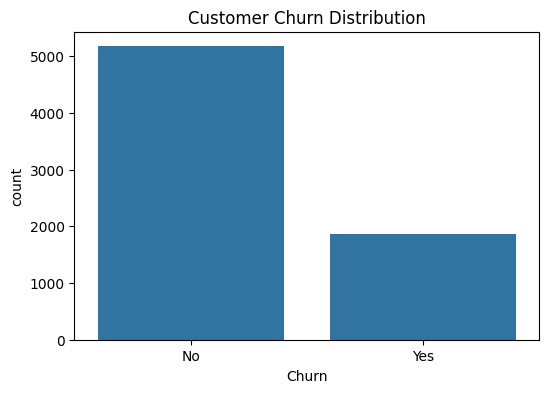

In [14]:
# Plot churn distribution using countplot
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title('Customer Churn Distribution')

plt.savefig('../reports/churn_distribution_bar.png')

plt.show()

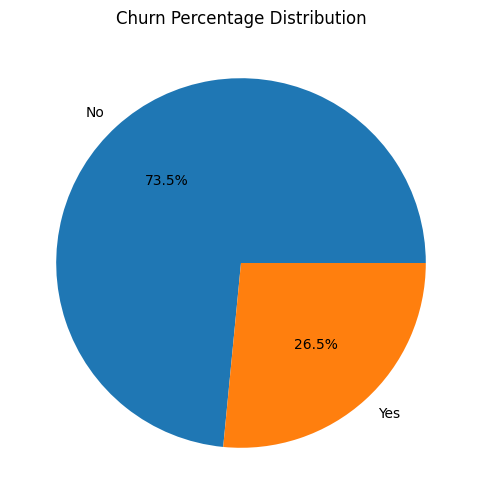

In [15]:
# Plot churn distribution using pie chart
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%'
)

plt.title('Churn Percentage Distribution')

plt.savefig('../reports/churn_distribution_pie.png')

plt.show()

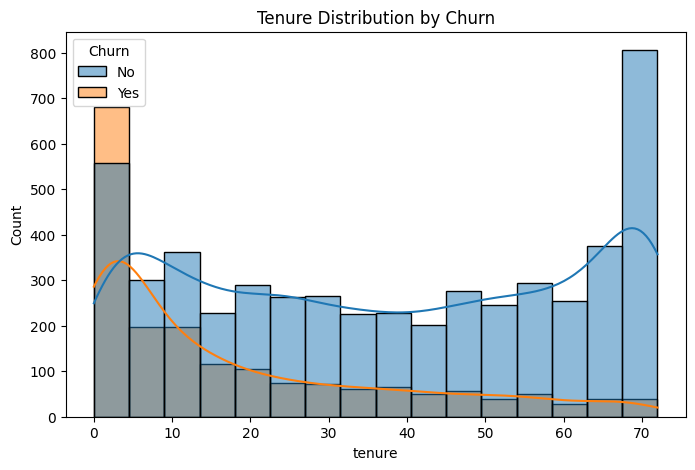

In [16]:
# Plot distribution of tenure based on churn
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True
)

plt.title('Tenure Distribution by Churn')

plt.savefig('../reports/tenure_distribution.png')

plt.show()

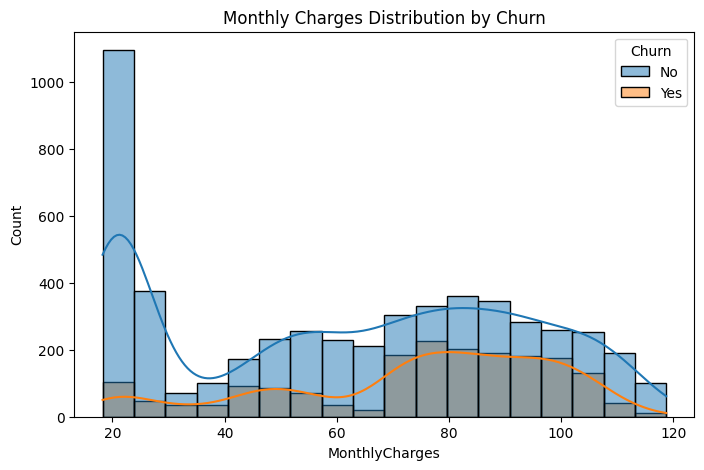

In [17]:
# Plot distribution of MonthlyCharges based on churn
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    kde=True
)

plt.title('Monthly Charges Distribution by Churn')

plt.savefig('../reports/monthlycharges_distribution.png')

plt.show()

In [18]:
# Convert Churn column into numeric values for correlation
df['Churn_Numeric'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [20]:
# Create correlation matrix
corr_matrix = df[
    ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']
].corr()

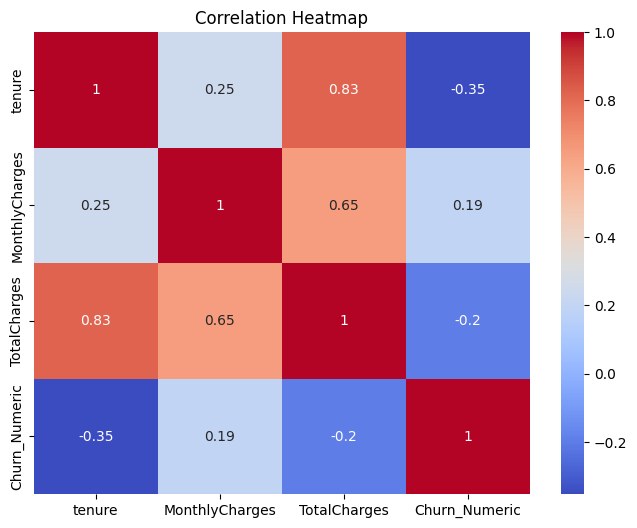

In [21]:
# Plot correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig('../reports/correlation_heatmap.png')

plt.show()

## Business Insight 1

Customers with month-to-month contracts have a significantly higher churn rate compared to customers with long-term contracts.

## Business Insight 2

Customers with higher monthly charges are more likely to churn.

## Business Insight 3

Customers with low tenure tend to churn more frequently than long-term customers.

## Business Insight 4

The dataset is imbalanced because the number of non-churn customers is much higher than churn customers.

## Business Insight 5

Tenure has a negative correlation with churn, meaning loyal customers are less likely to leave the company.